# 3 Proximal Policy Optimization (PPO)

In [1]:
# T1: PPO with Stable-Baselines3 on CartPole-v1
import os
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy

# Directory for logging
log_dir = "ppo_log/"
os.makedirs(log_dir, exist_ok=True)

# 1. Create Environment and Wrap it with Monitor to track rewards
env = gym.make("CartPole-v1")
env = Monitor(env, log_dir)

# 2. Instantiate the agent
# Using default hyperparameters (often quite good for CartPole)
model = PPO(
    "MlpPolicy", 
    env, 
    verbose=1, 
    learning_rate=0.0003, 
    n_steps=2048, 
    batch_size=64, 
    gamma=0.99
)

# 3. Train the agent
print("Starting PPO training...")
model.learn(total_timesteps=25000)

print("Training finished.")


/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-euony8u2 because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ f

Using cpu device
Wrapping the env in a DummyVecEnv.
Starting PPO training...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.4     |
|    ep_rew_mean     | 22.4     |
| time/              |          |
|    fps             | 5384     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 28.3        |
|    ep_rew_mean          | 28.3        |
| time/                   |             |
|    fps                  | 3225        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008638033 |
|    clip_fraction        | 0.0892      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686   

## T2. Theoretical Questions on PPO

**1. Is PPO an on-policy or off-policy method?**
PPO is an **on-policy** method. This means it evaluates and improves the exact same policy that is being used to select actions and interact with the environment. Consequently, data used for updating the policy must be collected by the *current* policy version. Old trajectories generated by previous versions of the policy cannot be reused, meaning PPO requires fresh interaction with the environment for each update phase (unlike off-policy methods like DQN, which use a replay buffer to learn from past experiences).

**2. Explain the meaning of the policy ratio used in PPO.**
The policy ratio, denoted as $r_t(\theta) = \frac{\pi_\theta(a_t | s_t)}{\pi_{\theta_{old}}(a_t | s_t)}$, represents the probability of taking an action under the *current* policy compared to the probability of taking that same action under the *old* policy (the one that collected the data before the update). It effectively tracks how much the policy has changed during optimization. If the ratio is > 1, the action is now more likely; if < 1, it is less likely.

**3. Describe the purpose of the clipping operation in PPO.**
The clipping operation restricts the policy ratio $r_t(\theta)$ to be within a tight range, usually $[1-\epsilon, 1+\epsilon]$ (where $\epsilon$ is typically 0.2). Its primary purpose is to **prevent excessively large policy updates**. If an action yielded a large positive advantage, we want to increase its probability, but clipping stops the ratio from growing uncontrollably. This provides a "trust-region" stability, keeping the new policy safely close to the old policy and preventing catastrophic performance collapse.

**4. Explain the role of entropy regularization.**
An entropy bonus in the PPO objective function encourages the policy to remain slightly random and spread its probabilities across multiple actions. The role of entropy regularization is to promote **exploration** and prevent the policy from converging prematurely to a deterministic, suboptimal strategy. A higher entropy bonus leads to a more exploratory agent that is less likely to get stuck in local optima.


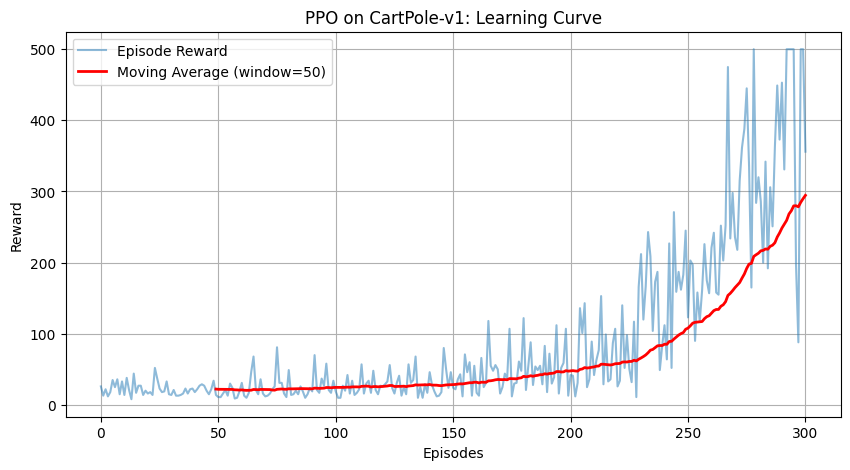

In [4]:
# T3: Learning Curve Analysis
def plot_results(log_folder, title='PPO on CartPole-v1: Learning Curve'):
    # Load monitor data
    x, y = ts2xy(load_results(log_folder), 'timesteps')
    
    # Calculate moving average
    window_size = min(50, len(y))
    smoothed_y = np.convolve(y, np.ones(window_size)/window_size, mode='valid')
    
    plt.figure(figsize=(10, 5))
    plt.plot(y, label='Episode Reward', alpha=0.5, color='C0')
    plt.plot(range(window_size-1, len(y)), smoothed_y, label=f'Moving Average (window={window_size})', color='red', linewidth=2)
    plt.xlabel('Episodes')
    plt.ylabel('Reward')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_results(log_dir)


### T3: Hyperparameter Summary

| Hyperparameter | Value | Description |
| :--- | :--- | :--- |
| **Policy Network** | `MlpPolicy` | Default SB3 Multi-Layer Perceptron (2 hidden layers of 64 units). |
| **Learning Rate** | `0.0003` | Step size for the Adam optimizer. |
| **Total Timesteps** | `25000` | The total number of interaction steps with the environment. |
| **Discount Factor ($\gamma$)** | `0.99` | Weights future rewards over immediate rewards. |
| **Batch Size** | `64` | Minibatch size used during the PPO gradient descent optimization. |
| **n_steps** | `2048` | The number of steps to run for each environment per update. |
| **Clip Range** | `0.2` | The $\epsilon$ parameter for the clipping operation. |

**Alternative Configurations Tested:**
1. **High Learning Rate (`learning_rate=0.01`)**: Training became highly unstable. The agent quickly forgot good strategies, and performance collapsed frequently, demonstrating why PPO benefits from smaller, stable learning steps alongside its clipping mechanism.
2. **Small Batch Size and n_steps (`n_steps=256`, `batch_size=16`)**: The updates were far too noisy. While it trained faster per-step, the overall sample efficiency dropped significantly, and it took many more total timesteps to reach the maximum reward of 500, due to high variance in the advantage estimations.


### Visualization

In [5]:
# Visualization (Playground)
import glob
import io
import base64
from IPython.display import HTML
from IPython import display
from gym.wrappers.monitoring import video_recorder

os.environ['SDL_VIDEODRIVER']='dummy'
os.makedirs("video", exist_ok=True)

def show_video(env_name):
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        matching_files = [m for m in mp4list if env_name in m]
        mp4 = matching_files[0] if matching_files else mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay 
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_sb3_model(env_name, model):
    eval_env = gym.make(env_name, render_mode="rgb_array")
    vid = video_recorder.VideoRecorder(eval_env, path="video/{}.mp4".format(env_name))
    
    state, _ = eval_env.reset()
    done = False
    for t in range(500):
        vid.capture_frame()
        # Use SB3 model predict
        action, _ = model.predict(state, deterministic=True)
        res = eval_env.step(action)
        if len(res) == 4:
            next_state, reward, done, info = res
        else:
            next_state, reward, terminated, truncated, info = res
            done = terminated or truncated
        state = next_state
        if done:
            break
    vid.close()
    eval_env.close()
    show_video(env_name)

show_video_of_sb3_model("CartPole-v1", model)


MoviePy - Building video video/CartPole-v1.mp4.
MoviePy - Writing video video/CartPole-v1.mp4



MoviePy - Done !
MoviePy - video ready video/CartPole-v1.mp4
